# Benchmark Model 2: Coordinates Only (`model_bench_coords.ipynb`)

This notebook trains a PyTorch LSTM model using **ONLY Landmark Coordinates** (8 features per step across 5 frame timesteps: $N, 5, 8$).

## 1. Imports & Hyperparameters Setup

In [49]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Set random seeds for reproducibility
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Hyperparameters
SEQ_LEN = 5          # 5 frame timesteps
FEATURE_DIM = 8      # 8 landmark coordinates per step
BATCH_SIZE = 32
LEARNING_RATE = 0.001
HIDDEN_UNITS = 32
DROPOUT = 0.2
EPOCHS = 100

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Load & Prepare Datasets (Coordinates Only)

In [50]:
def extract_coordinate_features(csv_path):
    df = pd.read_csv(csv_path)
    n_samples = len(df)
    X = np.zeros((n_samples, 5, 8), dtype=np.float32)
    
    for k in range(1, 6):
        coord_cols = [
            f"wrist{k}_x", f"wrist{k}_y",
            f"mcp{k}_x", f"mcp{k}_y",
            f"pip{k}_x", f"pip{k}_y",
            f"dip{k}_x", f"dip{k}_y"
        ]
        X[:, k - 1, :] = df[coord_cols].fillna(0.0).values.astype(np.float32)
        
    target_col = "touch_finger" if "touch_finger" in df.columns else "touch"
    y = df[target_col].astype(str).str.strip().str.lower().isin(["1", "true", "t", "yes", "y"]).values.astype(np.float32)
    y = y.reshape(-1, 1)
    
    return X, y

TRAIN_CSV = "./data/training_data.csv"
TEST_CSV = "./data/test_data.csv"

X_train_np, y_train_np = extract_coordinate_features(TRAIN_CSV)
X_test_np, y_test_np = extract_coordinate_features(TEST_CSV)

# Normalize using StandardScaler
scaler = StandardScaler()
N_tr, T, C = X_train_np.shape
N_te, _, _ = X_test_np.shape

X_train_flat = X_train_np.reshape(N_tr, -1)
X_test_flat = X_test_np.reshape(N_te, -1)

X_train_scaled = scaler.fit_transform(X_train_flat).reshape(N_tr, T, C)
X_test_scaled = scaler.transform(X_test_flat).reshape(N_te, T, C)

X_train = torch.from_numpy(X_train_scaled).type(torch.float32)
y_train = torch.from_numpy(y_train_np).type(torch.float32)
X_test = torch.from_numpy(X_test_scaled).type(torch.float32)
y_test = torch.from_numpy(y_test_np).type(torch.float32)

print(f"X_train shape (Coordinates Only): {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape  (Coordinates Only): {X_test.shape},  y_test shape:  {y_test.shape}")

X_train shape (Coordinates Only): torch.Size([2723, 5, 8]), y_train shape: torch.Size([2723, 1])
X_test shape  (Coordinates Only): torch.Size([224, 5, 8]),  y_test shape:  torch.Size([224, 1])


## 3. DataLoader Setup

In [51]:
class CoordDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(CoordDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(CoordDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

## 4. LSTM Architecture

In [52]:
class CoordLSTM(nn.Module):
    def __init__(self, input_features=8, hidden_units=32, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_features, hidden_size=hidden_units, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_units, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1)
        )
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.classifier(lstm_out[:, -1, :])

model_coords = CoordLSTM(input_features=FEATURE_DIM, hidden_units=HIDDEN_UNITS).to(device)
print(model_coords)

CoordLSTM(
  (lstm): LSTM(8, 32, num_layers=2, batch_first=True, dropout=0.2)
  (classifier): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 5. Training Loop

In [53]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_coords.parameters(), lr=LEARNING_RATE)

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(1, EPOCHS + 1):
    model_coords.train()
    tr_loss, tr_acc = 0.0, 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        logits = model_coords(X_b)
        loss = loss_fn(logits, y_b)
        preds = torch.round(torch.sigmoid(logits))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        tr_loss += loss.item() * len(X_b)
        tr_acc += (torch.eq(y_b, preds).sum().item() / len(y_b)) * len(X_b)
        
    train_loss = tr_loss / len(train_loader.dataset)
    train_acc = (tr_acc / len(train_loader.dataset)) * 100.0
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    model_coords.eval()
    te_loss, te_acc = 0.0, 0.0
    with torch.inference_mode():
        for X_b, y_b in test_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            logits = model_coords(X_b)
            loss = loss_fn(logits, y_b)
            preds = torch.round(torch.sigmoid(logits))
            
            te_loss += loss.item() * len(X_b)
            te_acc += (torch.eq(y_b, preds).sum().item() / len(y_b)) * len(X_b)
            
    test_loss = te_loss / len(test_loader.dataset)
    test_acc = (te_acc / len(test_loader.dataset)) * 100.0
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch: {epoch:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch: 01 | Train Loss: 0.6650 | Train Acc: 61.84% | Test Loss: 0.6817 | Test Acc: 51.34%
Epoch: 05 | Train Loss: 0.6185 | Train Acc: 66.21% | Test Loss: 0.7173 | Test Acc: 54.02%
Epoch: 10 | Train Loss: 0.5827 | Train Acc: 71.02% | Test Loss: 0.6417 | Test Acc: 63.39%
Epoch: 15 | Train Loss: 0.5224 | Train Acc: 74.88% | Test Loss: 0.6495 | Test Acc: 67.41%
Epoch: 20 | Train Loss: 0.4836 | Train Acc: 78.48% | Test Loss: 0.5734 | Test Acc: 70.54%
Epoch: 25 | Train Loss: 0.4602 | Train Acc: 79.73% | Test Loss: 0.5092 | Test Acc: 75.45%
Epoch: 30 | Train Loss: 0.4246 | Train Acc: 82.08% | Test Loss: 0.5221 | Test Acc: 75.45%
Epoch: 35 | Train Loss: 0.4009 | Train Acc: 82.56% | Test Loss: 0.4831 | Test Acc: 81.25%
Epoch: 40 | Train Loss: 0.3868 | Train Acc: 83.66% | Test Loss: 0.4723 | Test Acc: 81.70%
Epoch: 45 | Train Loss: 0.3618 | Train Acc: 84.91% | Test Loss: 0.4442 | Test Acc: 80.36%
Epoch: 50 | Train Loss: 0.3552 | Train Acc: 85.13% | Test Loss: 0.4298 | Test Acc: 83.04%
Epoch: 55 

## 6. Training & Testing Curves

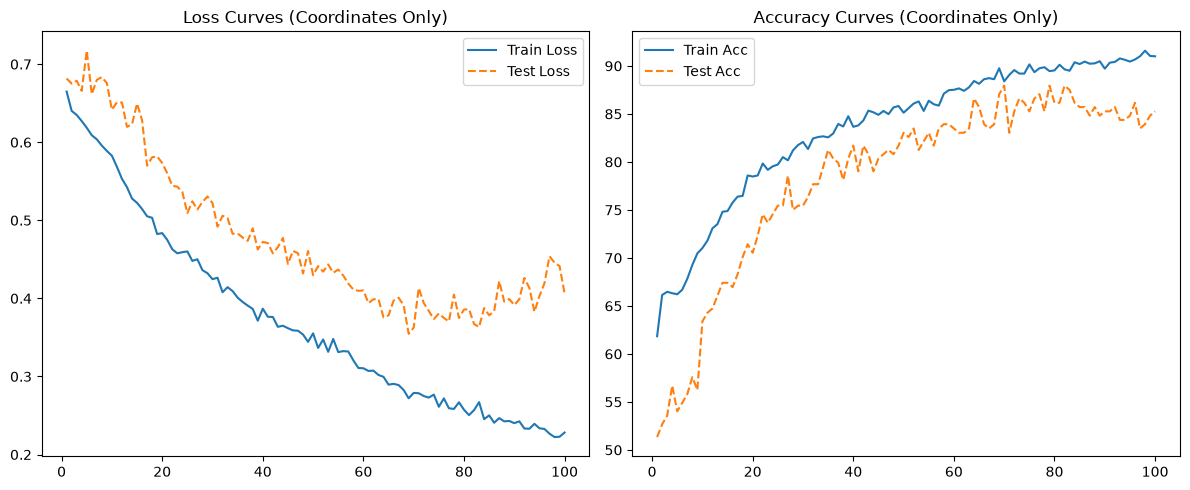

In [54]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), test_losses, label="Test Loss", linestyle="--")
plt.title("Loss Curves (Coordinates Only)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), train_accuracies, label="Train Acc")
plt.plot(range(1, EPOCHS + 1), test_accuracies, label="Test Acc", linestyle="--")
plt.title("Accuracy Curves (Coordinates Only)")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Model Evaluation Analytics (Confusion Matrix & Classification Report)


 CONFUSION MATRIX (Coordinates Only)
[[194  74]
 [ 65 149]]

Classification Report:
               precision    recall  f1-score   support

 Untouch (0)       0.75      0.72      0.74       268
   Touch (1)       0.67      0.70      0.68       214

    accuracy                           0.71       482
   macro avg       0.71      0.71      0.71       482
weighted avg       0.71      0.71      0.71       482



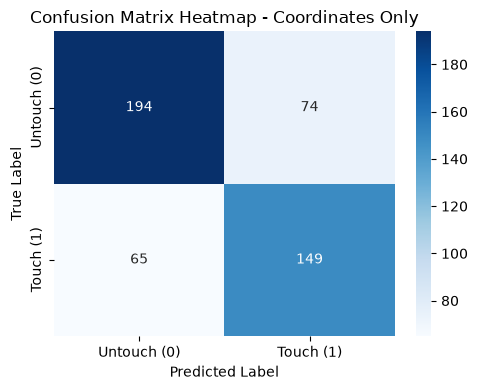

In [7]:
model_coords.eval()
all_preds, all_targets = [], []
with torch.inference_mode():
    for X_b, y_b in test_loader:
        logits = model_coords(X_b.to(device))
        preds = torch.round(torch.sigmoid(logits)).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(y_b.numpy())
        
all_preds = np.array(all_preds).squeeze()
all_targets = np.array(all_targets).squeeze()
cm = confusion_matrix(all_targets, all_preds)
labels = ["Untouch (0)", "Touch (1)"]

print("\n" + "="*50)
print(" CONFUSION MATRIX (Coordinates Only)")
print("="*50)
print(cm)
print("\nClassification Report:\n", classification_report(all_targets, all_preds, target_names=labels))
print("="*50)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix Heatmap - Coordinates Only")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## 8. Save Model Weights

In [8]:
torch.save(model_coords.state_dict(), "finger_touch_coords.pth")
print("Saved model weights to 'finger_touch_coords.pth'.")